
# GA Audit Explorer — 13 DAGs
This notebook provides a repeatable template to analyze multiple production graphs (DAGs) with three optimization strategies:
- **Flat GA** (binary genome end‑to‑end).
- **Exhaustive-by-class + tail** (prefix fixed per class-combo, GA on tail).
- **Joint GA** (selectors per primary good + tail).

For each case:
1. Render the graph in **topological order**, bottom → top.
2. Show a concise structural description of the graph.
3. Show the price matrix and summarize price semantics.
4. Run any of the three optimizers with per-case hyperparameters.
5. Show the maximizing genomes and basic transaction patterns.
6. Optionally **launch the interactive GUI** (`tests/test_Economy_GUI2.py`) to inspect ledgers and the production plan.


In [59]:

from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Resolve repository root (looks upward for common project markers)
_THIS = Path.cwd()
REPO_ROOT = _THIS
cur = _THIS
while cur != cur.parent:
    if (cur / "classes").exists() or (cur / "algorithms").exists() or (cur / "pyproject.toml").exists():
        REPO_ROOT = cur
        break
    cur = cur.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Domain imports
from classes.economy.economy import Economy

# GA implementations (real module names, no shims)
from algorithms.ga.flat import run_ga_flat
from algorithms.ga.equivclass_exhaustive import run_ga_equivclass_exhaustive
from algorithms.ga.equivclass_joint import run_ga_equivclass_joint
from algorithms.ga.joint_original import run_joint_original
from algorithms.ga.particle_swarm import run_pso
from algorithms.ga.eq_class_generic import run_eq_class_generic_ga
from algorithms.ga.equivclass_joint import run_ga_equivclass_joint
from algorithms.ga.macro_micro import run_ga_macro_micro
from algorithms.ga.recomb_only import run_ga_recomb_only




# Common helpers for detection / probing
from algorithms.ga.common import (
    make_transactions_builder,
    normalize_transactions,
    detect_prefix_layout_and_sizes,
    calibrate_min_len_via_builder,
    probe_allowed_indices_via_tx_builder,
)


In [60]:

# --- Agents configuration (single, reused by all cases)
ACCOUNTS_PATH = (REPO_ROOT / "chart_of_accounts.yaml")

BASE_AGENTS: Dict[str, Dict[str, Any]] = {
    "MKT": {
        "type": "MKT",
        "inventory_strategy": "FIFO",
        "firm_related_goods": [],
        "income_statement_type": "standard",
        "accounts_yaml_path": ACCOUNTS_PATH,
        "price_mapping": 0,
    },
    "NCT": {
        "type": "NCT",
        "inventory_strategy": "FIFO",
        "firm_related_goods": [],
        "income_statement_type": "standard",
        "accounts_yaml_path": ACCOUNTS_PATH,
        "price_mapping": 1,
    },
    "ZF": {
        "type": "ZF",
        "inventory_strategy": "FIFO",
        "firm_related_goods": [],
        "income_statement_type": "standard",
        "accounts_yaml_path": ACCOUNTS_PATH,
        "price_mapping": 2,
    },
}

def attach_goods_to_agents(agents: Dict[str, Dict[str, Any]], goods: List[str]) -> Dict[str, Dict[str, Any]]:
    out = {}
    for k, v in agents.items():
        d = dict(v)
        d["firm_related_goods"] = list(goods)
        out[k] = d
    return out


In [61]:
# --- Topological layout (top->bottom) and drawing utilities
def topo_vertical_layout(
    G: nx.DiGraph,
    layer_gap: float = 1.0,
    node_gap: float = 1.6,
    bottom_to_top: bool = False,          # ← ahora por defecto top->bottom
    stagger_singletons: bool = True,      # ← opcional: desplazar capas de 1 nodo
    singleton_dx: float = 0.8,            # ← cuánto desplazar en X
):
    """
    Positions nodes by topological generations. Sources first (top), sinks last (bottom).
    If a layer has a single node, optionally shift it horizontally so edges don't perfectly overlap.
    """
    if not nx.is_directed_acyclic_graph(G):
        return nx.spring_layout(G, seed=42)

    layers = list(nx.topological_generations(G))  # sources first, sinks last
    pos: Dict[Any, Tuple[float, float]] = {}
    L = len(layers)

    for li, layer in enumerate(layers):
        # top->bottom when bottom_to_top=False
        y = -li * layer_gap if bottom_to_top else li * layer_gap
        n = max(1, len(layer))

        if n == 1 and stagger_singletons:
            # shift singletons left/right progressively to avoid perfect vertical alignment
            x = (li - (L - 1) / 2.0) * singleton_dx
            pos[layer[0]] = (x, y)
        else:
            width = (n - 1) * node_gap
            x0 = -width / 2.0
            for j, node in enumerate(layer):
                pos[node] = (x0 + j * node_gap, y)
    return pos


def draw_dag_topo(G: nx.DiGraph, ax=None, title: Optional[str] = None):
    """
    Draw DAG with top->bottom orientation and curved edges to avoid overlap
    when multiple edges share the same vertical direction.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # top->bottom; also stagger singletons to reduce straight overlap
    pos = topo_vertical_layout(
        G, layer_gap=1.0, node_gap=1.6, bottom_to_top=False,
        stagger_singletons=True, singleton_dx=0.8
    )

    # --- Curved edges (fan-out by source) to prevent perfect overlap
    edge_color = '#555555'
    width = 1.4
    rad_step = 0.25  # curvature increment between sibling edges

    for u in G.nodes():
        targets = list(G.successors(u))
        k = len(targets)
        for idx, v in enumerate(targets):
            # center around 0, spread left/right: ..., -rad_step, 0, +rad_step, ...
            rad = (idx - (k - 1) / 2.0) * rad_step
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)], ax=ax,
                arrows=True, arrowstyle='-|>',
                width=width, edge_color=edge_color,
                connectionstyle=f'arc3,rad={rad}'
            )

    # Nodes & labels
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=600,
        node_color='#cfe8ff', edgecolors='#7aa7d7', linewidths=2.0
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_weight='bold')

    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return ax


In [62]:

# --- Price matrix summary helper
def describe_price_matrix(P: np.ndarray) -> pd.DataFrame:
    A = np.asarray(P, dtype=float)
    dims = A.shape
    flat = A.reshape(-1)
    return pd.DataFrame({
        "shape": [str(dims)],
        "min": [float(np.min(flat))],
        "max": [float(np.max(flat))],
        "mean": [float(np.mean(flat))],
        "dtype": [str(A.dtype)],
    })


In [ ]:

# --- Optimizer runners (uniform interface)

def run_flat_case(graph_links: List[Tuple[str, str]], P: np.ndarray, agents: Dict[str, Any], hp: Dict[str, Any]) -> Dict[str, Any]:
    # Infer a minimal genome length that Planner accepts
    txb = make_transactions_builder(graph_links)
    primary = sorted({u for u, v in graph_links if all(u != z for z, _ in graph_links)} | set())
    base_L = max(2, len(primary) + 1)
    L_min = calibrate_min_len_via_builder(txb, base_L=base_L)
    res = run_ga_flat(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        genome_shape=L_min,
        generations=hp.get("generations", 12),
        popsize=hp.get("popsize", 30),
        parents=hp.get("parents", 14),
        mutation_rate=hp.get("mutation_rate", 0.05),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 42),
    )
    return {"name": "flat", **res}

def run_exhaustive_case(graph_links: List[Tuple[str, str]], P: np.ndarray, agents: Dict[str, Any], hp: Dict[str, Any]) -> Dict[str, Any]:
    res = run_ga_equivclass_exhaustive(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        mode=hp.get("mode", "graph"),
        generations=hp.get("generations", 10),
        popsize=hp.get("popsize", 20),
        parents=hp.get("parents", 10),
        mutation_rate=hp.get("mutation_rate", 0.10),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 123),
        max_combos=hp.get("max_combos", 32),
        per_good_cap=hp.get("per_good_cap", None),
        max_index_probe=hp.get("max_index_probe", 8),
        verbosity=hp.get("verbosity", 0),
        log_every=hp.get("log_every", 1),
        no_plots=True,
        top_combos_bars=hp.get("top_combos_bars", 10),
    )
    return {"name": "exhaustive eq. class", **res}

def run_joint(graph_links: List[Tuple[str, str]], P: np.ndarray, agents: Dict[str, Any], hp: Dict[str, Any]) -> Dict[str, Any]:
    res = run_ga_equivclass_joint(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        mode=hp.get("mode", "graph"),
        generations=hp.get("generations", 12),
        popsize=hp.get("popsize", 28),
        parents=hp.get("parents", 12),
        elite_fraction=hp.get("elite_fraction", 0.25),
        tourn_size=hp.get("tourn_size", 3),
        sel_mutation=hp.get("sel_mutation", 0.20),
        tail_mutation=hp.get("tail_mutation", 0.05),
        per_good_cap=hp.get("per_good_cap", None),
        max_index_probe=hp.get("max_index_probe", 8),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 44),
        verbosity=hp.get("verbosity", 1),
        log_every=hp.get("log_every", 1),
    )
    return {"name": "joint", **res}


def run_old_joint(graph_links: List[Tuple[str, str]], P: np.ndarray, agents: Dict[str, Any], hp: Dict[str, Any]) -> Dict[str, Any]:
    res = run_joint_original(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        mode=hp.get("mode", "graph"),
        generations=hp.get("generations", 12),
        popsize=hp.get("popsize", 28),
        parents=hp.get("parents", 12),
        sel_mutation=hp.get("sel_mutation", 0.20),
        tail_mutation=hp.get("tail_mutation", 0.05),
        per_good_cap=hp.get("per_good_cap", None),
        max_index_probe=hp.get("max_index_probe", 8),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 44),
        verbosity=hp.get("verbosity", 1),
        log_every=hp.get("log_every", 1),
    )
    return {"name": "old joint", **res}

def run_pso_w1(
    graph_links: List[Tuple[str, str]],
    P: np.ndarray,
    agent_info_dict: Dict[str, Any],
    hp: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Execute the PSO for a single environment using the provided graph, prices, and hyperparameters.
    """
    txb = make_transactions_builder(graph_links)
    primary_nodes = [u for u, _ in graph_links if not any(v == u for _, v in graph_links)]

    base_L = max(2, len(primary_nodes) + 1)
    L_min = calibrate_min_len_via_builder(txb, base_L=base_L)
    genome_shape = L_min

    generations = hp.get("generations", 15)
    fix_last_gene = hp.get("fix_last_gene", True)
    c1 = hp.get("c1", 0.3)
    c2 = hp.get("c2", 0.3)
    w = hp.get("w", 0.9)
    popsize = hp.get("popsize", 30)
    seed = hp.get("seed", 42)
    verbosity = hp.get("verbosity", 1)

    res = run_pso(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agent_info_dict,
        genome_shape=genome_shape,
        generations=generations,
        popsize=popsize,
        c1=c1,
        c2=c2,
        w=w,
        fix_last_gene=fix_last_gene,
        seed=seed,
        verbosity=verbosity,
    )

    return {"algorithm": "pso", **res}

def run_eqclass_generic(
    graph_links: List[Tuple[str, str]],
    P: np.ndarray,
    agents: Dict[str, Any],
    hp: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Execute the equivalence-class GA where the genotype consists of:
      - an integer prefix (one gene per input/source good), and
      - a binary tail (derived from non-input path counts plus one extra bit).

    The genotype is mapped to a binary phenotype for `Economy` by expanding each
    integer k_i into a length-P_i block with exactly k_i ones (P_i is the number
    of directed paths from input i to the final good). The binary tail is appended
    as-is. The last gene/bit may be forcefully set to 1.

    Parameters
    ----------
    graph_links : list[tuple[str, str]]
        Directed edges of the production DAG.
    P : np.ndarray
        Price/parameter matrix forwarded to `Economy`.
    agents : dict
        Agent configuration forwarded to `Economy`.
    hp : dict
        Hyperparameters. Recognized keys (with defaults):
          - "final_good": node name of the final good (default: infer sink)
          - "generations": int = 12
          - "popsize": int = 28
          - "cxpb": float = 0.7
          - "mutpb": float = 0.2
          - "mutation_rate": float = 0.05            # tail bit flip indpb
          - "selector_mutation_rate": float = 0.25   # integer prefix indpb
          - "elitism": int = 1
          - "fix_last_gene": bool = True
          - "seed": int = 44
          - "verbosity": int = 1
          - "log_every": int = 1
          - "evals_cap": int | None = None
          - "time_limit_sec": float | None = None

    Returns
    -------
    dict
        A result dictionary augmented with a "name" key identifying the runner.
    """
    res = run_eq_class_generic_ga(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        final_good=hp.get("final_good", None),
        generations=hp.get("generations", 12),
        popsize=hp.get("popsize", 28),
        cxpb=hp.get("cxpb", 0.7),
        mutpb=hp.get("mutpb", 0.2),
        mutation_rate=hp.get("mutation_rate", 0.05),
        selector_mutation_rate=hp.get("selector_mutation_rate", 0.25),
        elitism=hp.get("elitism", 1),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 44),
        verbosity=hp.get("verbosity", 1),
        log_every=hp.get("log_every", 1),
        evals_cap=hp.get("evals_cap", None),
        time_limit_sec=hp.get("time_limit_sec", None),
    )
    return {"name": "eqclass generic", **res}


def run_macro_micro(
    graph_links: List[Tuple[str, str]],
    P: np.ndarray,
    agents: Dict[str, Any],
    hp: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Run the Macro→Micro GA with a uniform interface.

    Hyperparameters (hp) and defaults:
      - mode: str = "graph"
      - generations: int = 12
      - popsize: int = 28
      - parents: int = 12
      - elite_fraction: float = 0.25
      - tourn_size: int = 3
      - parent_selection: str = "tournament"
      - mating_selection: str = "pairwise_tournament"
      - lambda_in: float = 0.25
      - lambda_out: float = 0.50
      - p_macro: float = 1.00
      - p_micro: float = 1.00
      - sel_mutation: float = 0.25
      - tail_mutation: float = 0.05
      - p_min: float = 0.30
      - tau_percent: float | None = None
      - per_good_cap: int | None = None
      - max_index_probe: int = 8
      - fix_last_gene: bool = True
      - seed: int = 44
      - verbosity: int = 1
      - log_every: int = 1
      - evals_cap: int | None = None
      - time_limit_sec: float | None = None
    """
    res = run_ga_macro_micro(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        mode=hp.get("mode", "graph"),
        per_good_cap=hp.get("per_good_cap", None),
        max_index_probe=hp.get("max_index_probe", 8),
        generations=hp.get("generations", 12),
        popsize=hp.get("popsize", 28),
        parents=hp.get("parents", 12),
        elite_fraction=hp.get("elite_fraction", 0.25),
        tourn_size=hp.get("tourn_size", 3),
        parent_selection=hp.get("parent_selection","tournament"),
        mating_selection=hp.get("mating_selection", "pairwise_tournament"),
        lambda_in=hp.get("lambda_in", 0.25),
        lambda_out=hp.get("lambda_out", 0.50),
        p_macro=hp.get("p_macro", 1.00),
        p_micro=hp.get("p_micro", 1.00),
        sel_mutation=hp.get("sel_mutation", None),
        tail_mutation=hp.get("tail_mutation", None),
        p_min=hp.get("p_min", 0.30),
        tau_percent=hp.get("tau_percent", None),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 44),
        verbosity=hp.get("verbosity", 1),
        log_every=hp.get("log_every", 1),
        evals_cap=hp.get("evals_cap", None),
        time_limit_sec=hp.get("time_limit_sec", None),
    )
    return {"name": "macro_micro", **res}

def run_recomb_only(
    graph_links: List[Tuple[str, str]],
    P: np.ndarray,
    agents: Dict[str, Any],
    hp: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Run the Recombination-Only GA with a uniform interface.

    Hyperparameters (hp) and defaults:
      - mode: str = "graph"
      - generations: int = 12
      - popsize: int = 28
      - parents: int = 12
      - elite_fraction: float = 0.25
      - tourn_size: int = 3
      - parent_selection: str = "tournament"
      - mating_selection: str = "pairwise_tournament"
      - p_recomb: float = 0.50           # per-locus prob. of inheriting from parent1
      - sel_mutation: float = 0.25       # per-selector mutation prob.
      - tail_mutation: float = 0.05      # per-bit mutation prob. on tail
      - p_min: float = 0.30              # calibration target for selector step sizes
      - per_good_cap: int | None = None
      - max_index_probe: int = 8
      - fix_last_gene: bool = True
      - seed: int = 44
      - verbosity: int = 1
      - log_every: int = 1
      - evals_cap: int | None = None
      - time_limit_sec: float | None = None
    """
    res = run_ga_recomb_only(
        production_graph=graph_links,
        pmatrix=P,
        agents_information=agents,
        mode=hp.get("mode", "graph"),
        generations=hp.get("generations", 12),
        popsize=hp.get("popsize", 28),
        parents=hp.get("parents", 12),
        elite_fraction=hp.get("elite_fraction", 0.25),
        tourn_size=hp.get("tourn_size", 3),
        parent_selection=hp.get("parent_selection","tournament"),
        mating_selection=hp.get("mating_selection", "pairwise_tournament"),
        p_recomb=hp.get("p_recomb", 0.50),
        sel_mutation=hp.get("sel_mutation", None),
        tail_mutation=hp.get("tail_mutation", None),
        p_min=hp.get("p_min", 0.30),
        tau_percent=hp.get("tau_percent", None),
        per_good_cap=hp.get("per_good_cap", None),
        max_index_probe=hp.get("max_index_probe", 8),
        fix_last_gene=hp.get("fix_last_gene", True),
        seed=hp.get("seed", 44),
        verbosity=hp.get("verbosity", 1),
        log_every=hp.get("log_every", 1),
        evals_cap=hp.get("evals_cap", None),
        time_limit_sec=hp.get("time_limit_sec", None),
    )
    return {"name": "recomb", **res}



RUNNERS = {
    "flat": run_flat_case,
    "exhaustive": run_exhaustive_case,
    "old_joint": run_old_joint,
    "joint": run_joint,
    "run_pso": run_pso_w1,
    "generic": run_eqclass_generic,
    "macro_micro": run_macro_micro,
    "recomb": run_recomb_only 
}


In [ ]:

# --- Case scaffolding (start with one example)
CASES: Dict[str, Dict[str, Any]] = {
    "Example_1": {
        "graph":   [
  ("A","C"), ("A","D"), ("B","C"), ("B","D"), ("C","E"), ("D","E"),
  ("F","H"), ("F","I"), ("G","H"), ("G","I"), ("H","J"), ("I","J"),
  ("K","L"), ("L","M"),
  ("E","N"), ("J","N"), ("M","N"),
  ("N","O")
]

,
        "price_matrix": np.array([
            [[100, 100, 100],
             [100, 100, 100],
             [100, 100, 100]],

            [[110, 110, 110],
             [110, 110, 110],
             [110, 110, 110]],

            [[121, 121, 121],
             [121, 121, 121],
             [121, 121, 121]],

            [[133, 133, 133],
             [133, 133, 133],
             [133, 133, 133]],

            [[146, 146, 146],
             [146, 146, 146],
             [146, 146, 146]],

            [[160, 160, 160],
             [160, 160, 160],
             [160, 160, 160]],

            [[176, 176, 176],
             [176, 176, 176],
             [176, 176, 176]],

            [[193, 193, 193],
             [193, 193, 193],
             [193, 193, 193]],

            [[212, 212, 212],
             [212, 212, 212],
             [212, 212, 212]],

            [[233, 233, 233],
             [233, 233, 233],
             [233, 233, 233]],

            [[256, 256, 256],
             [256, 256, 256],
             [256, 256, 256]],

            [[281, 281, 281],
             [281, 281, 281],
             [281, 281, 281]],

            [[309, 309, 309],
             [309, 309, 309],
             [309, 309, 309]],

            [[339, 339, 339],
             [339, 339, 339],
             [339, 339, 339]],

            [[379, 379, 379],
             [372, 372, 372],
             [372, 372, 372]]
        ],
            dtype=int,
        ),
        # Per-method hyperparameters (easy to tweak per case)
        "hparams": {
            "flat":        {"generations": 10, "popsize": 30, "parents": 15, "mutation_rate": 0.05, "seed": 818},
            "exhaustive":  {"generations": 10, "popsize": 32, "parents": 15, "mutation_rate": 0.10, "max_combos": 20, "seed": 818, "verbosity": 0},
            "joint":       {"generations": 10, "popsize": 30, "parents": 15, "elite_fraction": 0.25, "tourn_size": 3, "sel_mutation": 0.20, "tail_mutation": 0.03, "seed": 818, "verbosity": 1,"log_every": 1},
            "old_joint":   {"generations": 10, "popsize": 30, "parents": 15, "sel_mutation": 0.20, "tail_mutation": 0.03, "seed": 818, "verbosity": 1,"log_every": 1},
            "run_pso":     {"generations": 10,  "popsize": 30, "c1": 0.729, "c2": 0.258, "w": 0.729, "fix_last_gene": True, "seed": 818,"verbosity": 1},
            "generic":     {"generations": 10, "popsize": 30, "cxpb": 0.8266, "mutpb": 0.4193, "mutation_rate": 0.1054, "selector_mutation_rate": 0.25, "elitism": 1, "fix_last_gene": True, "seed": 818, "verbosity": 1},
            "macro_micro": {"generations": 10, "popsize": 15, "parents": 5, "elite_fraction": 0.30, "tourn_size": 3, "mating_selection": "pairwise_tournament", "lambda_in": 0.1, "lambda_out": 0.15, "p_macro": 1.00, "p_micro": 1.00, "sel_mutation": None, "tail_mutation": None, "p_min": 0.30, "tau_percent": None, "fix_last_gene": True, "seed": 818, "verbosity": 1, "log_every": 1 },
            "recomb":      {"generations": 10, "popsize": 30, "parents": 15, "elite_fraction": 0.60, "tourn_size": 3,  "mating_selection": "pairwise_tournament", "inherit_prob": 0.50, "sel_mutation": None, "tail_mutation": None, "p_min": 0.30, "tau_percent": None, "fix_last_gene": True, "seed": 818, "verbosity": 1, "log_every": 1},
        # Free-form notes (analyst can fill after running)
        "notes": "",
    },
}
}
METHOD ="macro_micro"  # one of: "flat", "exhaustive", "old_joint", "joint", "pso", "generic", "macro_micro","recomb"


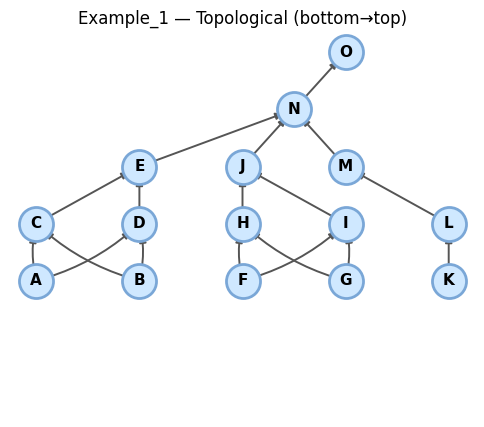

Graph summary:
  nodes=15  edges=18  depth=5
  sources=['A', 'B', 'F', 'G', 'K']  sinks=['O']


,shape,min,max,mean,dtype
0,"(15, 3, 3)",100.0,379.0,209.555556,float64


=== Macro→Micro GA detection summary ===
Goods (Planner order)       : ['A', 'B', 'F', 'G', 'K']
k_g per good                : [2, 2, 2, 2, 1]  ->  K=9 | L_used=20
Alphabet for prefix         : [0, 1]  (|A|=2)
Per-good pool sizes         : [3, 3, 3, 3, 2]  (≈ product 162)
Internal chromosome         : selectors=5, tail=11 (total=16)
Operators                   : p_macro=1.0, p_micro=1.0, λ_in=0.1, λ_out=0.15, tourn_size=3, sel_mut=0.0625, tail_mut=0.0625 , mating=pairwise_tournament
Gen 000: best=-461.050000 | mean=-506.250000 | median=-494.050000 | pheno_div=0.4676 | uniq=15
Gen 001: best=-445.450000 | mean=-480.670000 | median=-464.500000 | pheno_div=0.4364 | uniq=11
Gen 002: best=-445.450000 | mean=-455.730000 | median=-455.500000 | pheno_div=0.3818 | uniq=11
Gen 003: best=-434.800000 | mean=-459.670000 | median=-446.950000 | pheno_div=0.3527 | uniq=10
Gen 004: best=-427.450000 | mean=-462.890000 | median=-445.450000 | pheno_div=0.2927 | uniq=11
Gen 005: best=-427.450000 | mean=-453

In [65]:
# --- Run selected case end-to-end
case_key = "Example_1"
CASE = CASES[case_key]

G_links: List[Tuple[str, str]] = CASE["graph"]
P = CASE["price_matrix"]

# Agents attached with graph's goods
goods = sorted({n for u, v in G_links for n in (u, v)})
AGENTS = attach_goods_to_agents(BASE_AGENTS, goods)

# 1) Graph rendering (topological, bottom->top)
G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"{case_key} — Topological (bottom→top)")
plt.show()

# 2) Structural description
sources = [n for n, d in G.in_degree() if d == 0]
sinks = [n for n, d in G.out_degree() if d == 0]
depth = len(list(nx.topological_generations(G))) if nx.is_directed_acyclic_graph(G) else None
print("Graph summary:")
print(f"  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}  depth={depth}")
print(f"  sources={sources}  sinks={sinks}")

# 3) Price matrix description
display(describe_price_matrix(P))

# 4) Optimization
runner = RUNNERS[METHOD]
hp = CASE["hparams"][METHOD]
res = runner(G_links, P, AGENTS, hp)

# Standardize outputs across methods
best_genome = np.array(res["best_genome"], dtype=int)
best_utility = float(res.get("best_utility") or res.get("best_fitness") or res.get("best_score", 0.0))

print("\nOptimization result:")
print(f"  method         : {METHOD}")
print(f"  best_utility   : {best_utility:.6f}")
print(f"  best_genome    : {best_genome.tolist()}")
if "meta" in res:
    print(f"  meta           : {res['meta']}")

# 4bis) All maximizing genomes (ties)
def _as_list(g):
    return list(map(int, np.asarray(g, dtype=int).tolist()))

# Obtain directly what the runner returns; if not present, falls back to best_genome
maximizers_raw = res.get("all_best_genomes", [best_genome.tolist()])

# Deduplicate preserving order
seen = set()
maximizers = []
for g in maximizers_raw:
    key = tuple(_as_list(g))
    if key not in seen:
        seen.add(key)
        maximizers.append(list(key))

total_maximizers = len(maximizers)
show_k = min(10, total_maximizers)

print("\nMaximizing genomes (ties):")
print(f"  total = {total_maximizers} (showing up to {show_k})")
for i, g in enumerate(maximizers[:show_k], 1):
    print(f"  #{i:02d}: {g}")

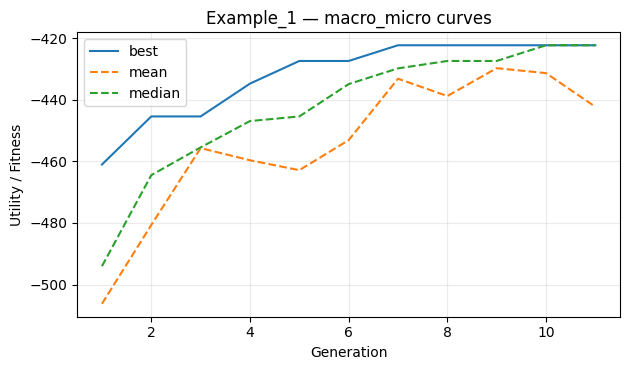

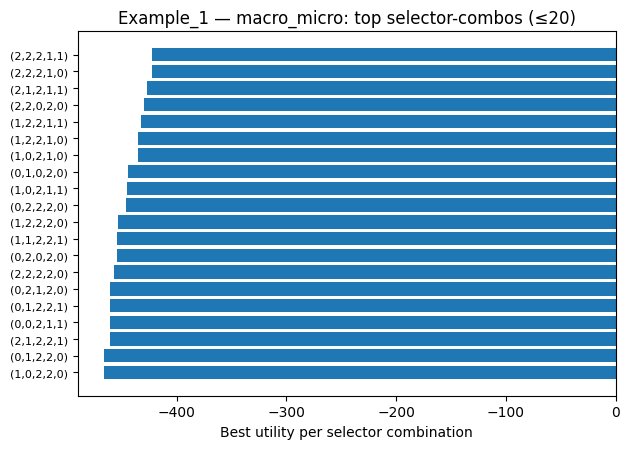

In [66]:
# GA plots (no file saving, notebook-only rendering)

def _extract_series_for_plot(curves: dict):
    """
    Normalizes the runner's 'curves' dict into a list of series to plot.
    It supports:
      - Flat/Joint GA: keys 'best', 'mean', 'median'
      - Exhaustive GA: keys 'best_combo_best', 'best_combo_mean', 'global_best', 'global_mean'
    Returns a list of tuples: (label, y_values, linestyle).
    """
    series = []
    if not curves:
        return series

    # Flat / Joint runners
    if curves.get("best"):
        series.append(("best",   curves["best"],   "-"))
    if curves.get("mean"):
        series.append(("mean",   curves["mean"],   "--"))
    if curves.get("median"):
        series.append(("median", curves["median"], "--"))

    # Exhaustive runner
    if curves.get("best_combo_best"):
        series.append(("best combo (best)", curves["best_combo_best"], "-"))
    if curves.get("best_combo_mean"):
        series.append(("best combo (mean)", curves["best_combo_mean"], "--"))
    if curves.get("global_best"):
        series.append(("global (best)",     curves["global_best"],     "-"))
    if curves.get("global_mean"):
        series.append(("global (mean)",     curves["global_mean"],     "--"))

    return series


def plot_ga_result(res: dict, method: str, case_key: str):
    """
    Plots GA evolution curves based on the runner's standardized output.
    It does not save any files; it only shows figures in the notebook.
    If 'best_by_selectors' is present (joint GA), it also renders a small bar chart.
    """
    curves = res.get("curves", {}) or {}
    series = _extract_series_for_plot(curves)

    # Evolution curves
    if series:
        fig = plt.figure(figsize=(6.4, 3.8))
        ax = fig.add_subplot(111)
        for label, y, ls in series:
            if not y:
                continue
            x = range(1, len(y) + 1)
            ax.plot(x, y, linestyle=ls, label=label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Utility / Fitness")
        title = f"{case_key} — {method} curves"
        meta = res.get("meta") or {}
        if "num_best_genomes" in meta:
            title += f" (ties={meta['num_best_genomes']})"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()
    else:
        print("No curve data to plot in res['curves'].")

    # Diagnostic chart for joint GA (if provided)
    bsel = res.get("best_by_selectors")
    if bsel:
        # bsel is a list of (selector_tuple_str, best_utility), sorted desc by utility.
        labels = [k for k, _ in bsel[:20]]
        vals   = [float(v) for _k, v in bsel[:20]]
        fig2 = plt.figure(figsize=(6.4, 4.6))
        ax2 = fig2.add_subplot(111)
        y_pos = list(range(len(labels)))[::-1]
        ax2.barh(y_pos, vals)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Best utility per selector combination")
        ax2.set_title(f"{case_key} — {method}: top selector-combos (≤20)")
        fig2.tight_layout()
        plt.show()


# Invoke plotting for the current run (no saving)
plot_ga_result(res, METHOD, case_key)


In [67]:
# --- Optional: launch interactive GUI to inspect the optimum

import subprocess
import sys
import os 
import json
from textwrap import indent
from pathlib import Path
import numpy as np

# --- 1. Define REPO_ROOT and GUI_PATH ---

REPO_ROOT = Path.cwd().parent
GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"

# --- 2. Data Preparation for GUI Injection ---
# Prepare string representations of the data that the GUI expects in the exact format.
# IMPORTANT: Convert NumPy arrays to string representations that ast.literal_eval can read (lists/arrays).
# The GUI's 'safe_eval_list' relies on this string format.
graph_links_str = str(G_links)
price_matrix_str = str(P.tolist()).replace('],', '],\n').replace('[[[', '[[[\n') # Formatting for readability in the GUI
genome_str = str(best_genome.tolist())

# --- 3. Set Environment Variables BEFORE Launching Subprocess ---
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = genome_str
os.environ["ECON_AUTO_RUN"] = "1" # Optionally, tell the GUI to run the model automatically

# ------------------------------------------

print("GUI handoff summary:")
print("graph_links =")
print(indent(graph_links_str, "  "))
print("price_matrix shape:", P.shape)
print("best_genome length:", len(best_genome))
print(f"GUI path check: {GUI_PATH.exists()}")

def launch_gui(open_now: bool = True):
    """
    Launches the external GUI script by setting environment variables for data transfer.
    """
    if not GUI_PATH.exists():
        print(f"GUI script not found at: {GUI_PATH}")
        return
    
    # The command needs to launch the Python executable with the script path.
    cmd_list = [
        sys.executable,        # Full path to the Python executable
        str(GUI_PATH)          # Full path to the GUI script
    ]
    
    print("Launching:", " ".join(cmd_list))
    
    if open_now:
        # Popen is called. The environment variables set above will be passed to this subprocess.
        subprocess.Popen(cmd_list, shell=False)

# The flag is set to True to open the GUI immediately after this cell runs.
open_immediately = True

if open_immediately:
    launch_gui(open_now=True)

# IMPORTANT: Reset environment variables after launch to avoid polluting future notebook runs
del os.environ["ECON_LINKS"]
del os.environ["ECON_PRICE_MATRIX"]
del os.environ["ECON_GENOME"]
del os.environ["ECON_AUTO_RUN"]

GUI handoff summary:
graph_links =
  [('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('F', 'H'), ('F', 'I'), ('G', 'H'), ('G', 'I'), ('H', 'J'), ('I', 'J'), ('K', 'L'), ('L', 'M'), ('E', 'N'), ('J', 'N'), ('M', 'N'), ('N', 'O')]
price_matrix shape: (15, 3, 3)
best_genome length: 20
GUI path check: True
Launching: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py


## Using another Ga to compare results.

In [68]:
METHOD = "joint"

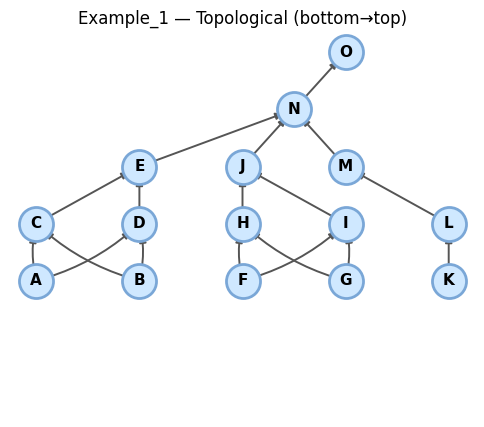

Graph summary:
  nodes=15  edges=18  depth=5
  sources=['A', 'B', 'F', 'G', 'K']  sinks=['O']


,shape,min,max,mean,dtype
0,"(15, 3, 3)",100.0,379.0,209.555556,float64


=== Joint GA detection summary ===
Goods (Planner order): ['A', 'B', 'F', 'G', 'K']
k_g per good: [2, 2, 2, 2, 1]  ->  K=9 | L_used=20
Alphabet for prefix: [0, 1]  (|A|=2)
Per-good pool sizes: [3, 3, 3, 3, 2]  (≈ product 162)
Internal chromosome: selectors=5, tail=11 (total=16)


KeyboardInterrupt: 

In [69]:
# --- Run selected case end-to-end
case_key = "Example_1"
CASE = CASES[case_key]

G_links: List[Tuple[str, str]] = CASE["graph"]
P = CASE["price_matrix"]

# Agents attached with graph's goods
goods = sorted({n for u, v in G_links for n in (u, v)})
AGENTS = attach_goods_to_agents(BASE_AGENTS, goods)

# 1) Graph rendering (topological, bottom->top)
G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"{case_key} — Topological (bottom→top)")
plt.show()

# 2) Structural description
sources = [n for n, d in G.in_degree() if d == 0]
sinks = [n for n, d in G.out_degree() if d == 0]
depth = len(list(nx.topological_generations(G))) if nx.is_directed_acyclic_graph(G) else None
print("Graph summary:")
print(f"  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}  depth={depth}")
print(f"  sources={sources}  sinks={sinks}")

# 3) Price matrix description
display(describe_price_matrix(P))

# 4) Optimization
runner = RUNNERS[METHOD]
hp = CASE["hparams"][METHOD]
res = runner(G_links, P, AGENTS, hp)

# Standardize outputs across methods
best_genome = np.array(res["best_genome"], dtype=int)
best_utility = float(res.get("best_utility") or res.get("best_fitness") or res.get("best_score", 0.0))

print("\nOptimization result:")
print(f"  method         : {METHOD}")
print(f"  best_utility   : {best_utility:.6f}")
print(f"  best_genome    : {best_genome.tolist()}")
if "meta" in res:
    print(f"  meta           : {res['meta']}")

# 4bis) All maximizing genomes (ties)
def _as_list(g):
    return list(map(int, np.asarray(g, dtype=int).tolist()))

# Obtain directly what the runner returns; if not present, falls back to best_genome
maximizers_raw = res.get("all_best_genomes", [best_genome.tolist()])

# Deduplicate preserving order
seen = set()
maximizers = []
for g in maximizers_raw:
    key = tuple(_as_list(g))
    if key not in seen:
        seen.add(key)
        maximizers.append(list(key))

total_maximizers = len(maximizers)
show_k = min(10, total_maximizers)

print("\nMaximizing genomes (ties):")
print(f"  total = {total_maximizers} (showing up to {show_k})")
for i, g in enumerate(maximizers[:show_k], 1):
    print(f"  #{i:02d}: {g}")

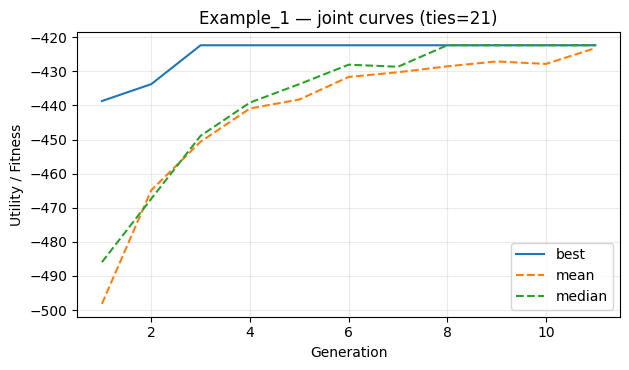

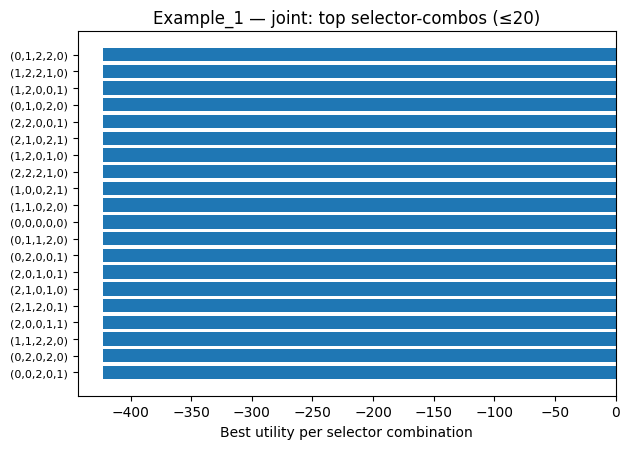

In [ ]:
# GA plots (no file saving, notebook-only rendering)

def _extract_series_for_plot(curves: dict):
    """
    Normalizes the runner's 'curves' dict into a list of series to plot.
    It supports:
      - Flat/Joint GA: keys 'best', 'mean', 'median'
      - Exhaustive GA: keys 'best_combo_best', 'best_combo_mean', 'global_best', 'global_mean'
    Returns a list of tuples: (label, y_values, linestyle).
    """
    series = []
    if not curves:
        return series

    # Flat / Joint runners
    if curves.get("best"):
        series.append(("best",   curves["best"],   "-"))
    if curves.get("mean"):
        series.append(("mean",   curves["mean"],   "--"))
    if curves.get("median"):
        series.append(("median", curves["median"], "--"))

    # Exhaustive runner
    if curves.get("best_combo_best"):
        series.append(("best combo (best)", curves["best_combo_best"], "-"))
    if curves.get("best_combo_mean"):
        series.append(("best combo (mean)", curves["best_combo_mean"], "--"))
    if curves.get("global_best"):
        series.append(("global (best)",     curves["global_best"],     "-"))
    if curves.get("global_mean"):
        series.append(("global (mean)",     curves["global_mean"],     "--"))

    return series


def plot_ga_result(res: dict, method: str, case_key: str):
    """
    Plots GA evolution curves based on the runner's standardized output.
    It does not save any files; it only shows figures in the notebook.
    If 'best_by_selectors' is present (joint GA), it also renders a small bar chart.
    """
    curves = res.get("curves", {}) or {}
    series = _extract_series_for_plot(curves)

    # Evolution curves
    if series:
        fig = plt.figure(figsize=(6.4, 3.8))
        ax = fig.add_subplot(111)
        for label, y, ls in series:
            if not y:
                continue
            x = range(1, len(y) + 1)
            ax.plot(x, y, linestyle=ls, label=label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Utility / Fitness")
        title = f"{case_key} — {method} curves"
        meta = res.get("meta") or {}
        if "num_best_genomes" in meta:
            title += f" (ties={meta['num_best_genomes']})"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()
    else:
        print("No curve data to plot in res['curves'].")

    # Diagnostic chart for joint GA (if provided)
    bsel = res.get("best_by_selectors")
    if bsel:
        # bsel is a list of (selector_tuple_str, best_utility), sorted desc by utility.
        labels = [k for k, _ in bsel[:20]]
        vals   = [float(v) for _k, v in bsel[:20]]
        fig2 = plt.figure(figsize=(6.4, 4.6))
        ax2 = fig2.add_subplot(111)
        y_pos = list(range(len(labels)))[::-1]
        ax2.barh(y_pos, vals)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Best utility per selector combination")
        ax2.set_title(f"{case_key} — {method}: top selector-combos (≤20)")
        fig2.tight_layout()
        plt.show()


# Invoke plotting for the current run (no saving)
plot_ga_result(res, METHOD, case_key)


In [ ]:
# --- Optional: launch interactive GUI to inspect the optimum

import subprocess
import sys
import os 
import json
from textwrap import indent
from pathlib import Path
import numpy as np

# --- 1. Define REPO_ROOT and GUI_PATH ---

REPO_ROOT = Path.cwd().parent
GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"

# --- 2. Data Preparation for GUI Injection ---
# Prepare string representations of the data that the GUI expects in the exact format.
# IMPORTANT: Convert NumPy arrays to string representations that ast.literal_eval can read (lists/arrays).
# The GUI's 'safe_eval_list' relies on this string format.
graph_links_str = str(G_links)
price_matrix_str = str(P.tolist()).replace('],', '],\n').replace('[[[', '[[[\n') # Formatting for readability in the GUI
genome_str = str(best_genome.tolist())

# --- 3. Set Environment Variables BEFORE Launching Subprocess ---
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = genome_str
os.environ["ECON_AUTO_RUN"] = "1" # Optionally, tell the GUI to run the model automatically

# ------------------------------------------

print("GUI handoff summary:")
print("graph_links =")
print(indent(graph_links_str, "  "))
print("price_matrix shape:", P.shape)
print("best_genome length:", len(best_genome))
print(f"GUI path check: {GUI_PATH.exists()}")

def launch_gui(open_now: bool = True):
    """
    Launches the external GUI script by setting environment variables for data transfer.
    """
    if not GUI_PATH.exists():
        print(f"GUI script not found at: {GUI_PATH}")
        return
    
    # The command needs to launch the Python executable with the script path.
    cmd_list = [
        sys.executable,        # Full path to the Python executable
        str(GUI_PATH)          # Full path to the GUI script
    ]
    
    print("Launching:", " ".join(cmd_list))
    
    if open_now:
        # Popen is called. The environment variables set above will be passed to this subprocess.
        subprocess.Popen(cmd_list, shell=False)

# The flag is set to True to open the GUI immediately after this cell runs.
open_immediately = True

if open_immediately:
    launch_gui(open_now=True)

# IMPORTANT: Reset environment variables after launch to avoid polluting future notebook runs
del os.environ["ECON_LINKS"]
del os.environ["ECON_PRICE_MATRIX"]
del os.environ["ECON_GENOME"]
del os.environ["ECON_AUTO_RUN"]

GUI handoff summary:
graph_links =
  [('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('F', 'H'), ('F', 'I'), ('G', 'H'), ('G', 'I'), ('H', 'J'), ('I', 'J'), ('K', 'L'), ('L', 'M'), ('E', 'N'), ('J', 'N'), ('M', 'N'), ('N', 'O')]
price_matrix shape: (15, 3, 3)
best_genome length: 20
GUI path check: True
Launching: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py



## Adding more cases

Duplicate the `Example_1` entry in `CASES` and modify:
- `graph`: edge list for the DAG.
- `price_matrix`: numpy-like nested list or `np.array(...)` with the appropriate shape.
- `hparams`: per-method hyperparameters.

Set `case_key` and `METHOD` accordingly, then re-run the end-to-end cell.


In [ ]:
METHOD = "generic"

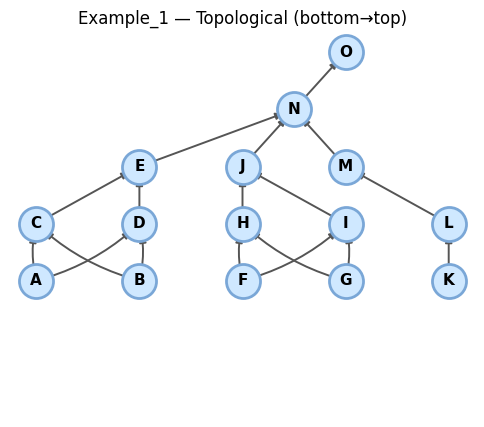

Graph summary:
  nodes=15  edges=18  depth=5
  sources=['A', 'B', 'F', 'G', 'K']  sinks=['O']


,shape,min,max,mean,dtype
0,"(15, 3, 3)",100.0,379.0,209.555556,float64


=== eq_class_generic_ga | Mapping summary ===
Final good: 'O'
Inputs (topological): ['A', 'B', 'F', 'G', 'K']
P_i per input: [2, 2, 2, 2, 1]  -> expanded_prefix_bits=9
Non-inputs considered: ['C', 'D', 'H', 'I', 'L', 'E', 'J', 'M', 'N', 'O']
tail_len = sum_paths(non-inputs) + 1 = 11
genotype_len = 16 = inputs(5) + tail(11)
Gen 000: best=-438.700000 | mean=-498.165000 | median=-485.950000
Gen 001: best=-438.700000 | mean=-478.190000 | median=-473.650000
Gen 002: best=-438.700000 | mean=-466.340000 | median=-466.300000
Gen 003: best=-422.350000 | mean=-452.035000 | median=-451.300000
Gen 004: best=-422.350000 | mean=-446.925000 | median=-438.700000
Gen 005: best=-422.350000 | mean=-437.690000 | median=-438.700000
Gen 006: best=-422.350000 | mean=-437.890000 | median=-433.750000
Gen 007: best=-422.350000 | mean=-430.510000 | median=-424.825000
Gen 008: best=-422.350000 | mean=-431.095000 | median=-422.350000
Gen 009: best=-422.350000 | mean=-432.960000 | median=-422.350000
Gen 010: best=-

In [ ]:
# --- Run selected case end-to-end
case_key = "Example_1"
CASE = CASES[case_key]

G_links: List[Tuple[str, str]] = CASE["graph"]
P = CASE["price_matrix"]

# Agents attached with graph's goods
goods = sorted({n for u, v in G_links for n in (u, v)})
AGENTS = attach_goods_to_agents(BASE_AGENTS, goods)

# 1) Graph rendering (topological, bottom->top)
G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"{case_key} — Topological (bottom→top)")
plt.show()

# 2) Structural description
sources = [n for n, d in G.in_degree() if d == 0]
sinks = [n for n, d in G.out_degree() if d == 0]
depth = len(list(nx.topological_generations(G))) if nx.is_directed_acyclic_graph(G) else None
print("Graph summary:")
print(f"  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}  depth={depth}")
print(f"  sources={sources}  sinks={sinks}")

# 3) Price matrix description
display(describe_price_matrix(P))

# 4) Optimization
runner = RUNNERS[METHOD]
hp = CASE["hparams"][METHOD]
res = runner(G_links, P, AGENTS, hp)

# Standardize outputs across methods
best_genome = np.array(res["best_genome"], dtype=int)
best_utility = float(res.get("best_utility") or res.get("best_fitness") or res.get("best_score", 0.0))

print("\nOptimization result:")
print(f"  method         : {METHOD}")
print(f"  best_utility   : {best_utility:.6f}")
print(f"  best_genome    : {best_genome.tolist()}")
if "meta" in res:
    print(f"  meta           : {res['meta']}")

# 4bis) All maximizing genomes (ties)
def _as_list(g):
    return list(map(int, np.asarray(g, dtype=int).tolist()))

# Obtain directly what the runner returns; if not present, falls back to best_genome
maximizers_raw = res.get("all_best_genomes", [best_genome.tolist()])

# Deduplicate preserving order
seen = set()
maximizers = []
for g in maximizers_raw:
    key = tuple(_as_list(g))
    if key not in seen:
        seen.add(key)
        maximizers.append(list(key))

total_maximizers = len(maximizers)
show_k = min(10, total_maximizers)

print("\nMaximizing genomes (ties):")
print(f"  total = {total_maximizers} (showing up to {show_k})")
for i, g in enumerate(maximizers[:show_k], 1):
    print(f"  #{i:02d}: {g}")

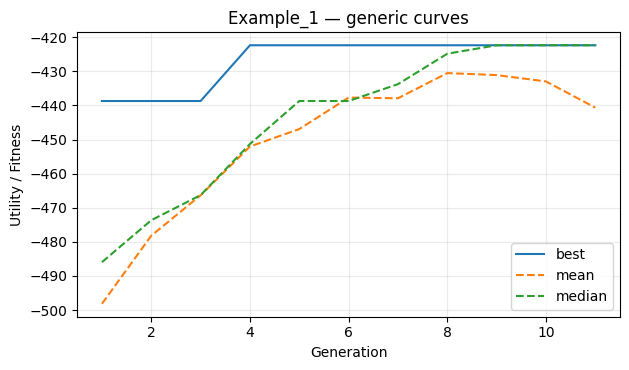

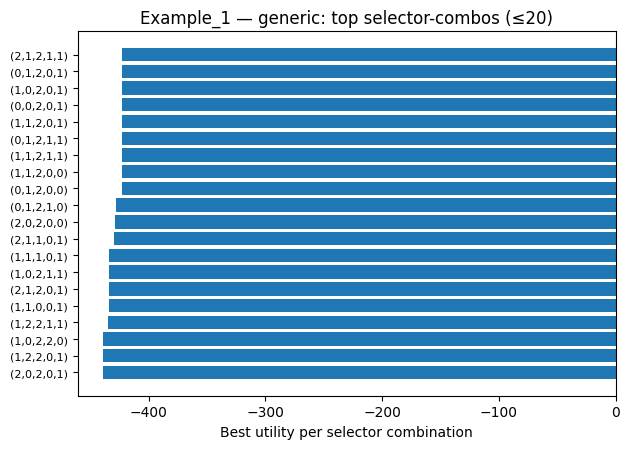

In [ ]:
# GA plots (no file saving, notebook-only rendering)

def _extract_series_for_plot(curves: dict):
    """
    Normalizes the runner's 'curves' dict into a list of series to plot.
    It supports:
      - Flat/Joint GA: keys 'best', 'mean', 'median'
      - Exhaustive GA: keys 'best_combo_best', 'best_combo_mean', 'global_best', 'global_mean'
    Returns a list of tuples: (label, y_values, linestyle).
    """
    series = []
    if not curves:
        return series

    # Flat / Joint runners
    if curves.get("best"):
        series.append(("best",   curves["best"],   "-"))
    if curves.get("mean"):
        series.append(("mean",   curves["mean"],   "--"))
    if curves.get("median"):
        series.append(("median", curves["median"], "--"))

    # Exhaustive runner
    if curves.get("best_combo_best"):
        series.append(("best combo (best)", curves["best_combo_best"], "-"))
    if curves.get("best_combo_mean"):
        series.append(("best combo (mean)", curves["best_combo_mean"], "--"))
    if curves.get("global_best"):
        series.append(("global (best)",     curves["global_best"],     "-"))
    if curves.get("global_mean"):
        series.append(("global (mean)",     curves["global_mean"],     "--"))

    return series


def plot_ga_result(res: dict, method: str, case_key: str):
    """
    Plots GA evolution curves based on the runner's standardized output.
    It does not save any files; it only shows figures in the notebook.
    If 'best_by_selectors' is present (joint GA), it also renders a small bar chart.
    """
    curves = res.get("curves", {}) or {}
    series = _extract_series_for_plot(curves)

    # Evolution curves
    if series:
        fig = plt.figure(figsize=(6.4, 3.8))
        ax = fig.add_subplot(111)
        for label, y, ls in series:
            if not y:
                continue
            x = range(1, len(y) + 1)
            ax.plot(x, y, linestyle=ls, label=label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Utility / Fitness")
        title = f"{case_key} — {method} curves"
        meta = res.get("meta") or {}
        if "num_best_genomes" in meta:
            title += f" (ties={meta['num_best_genomes']})"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()
    else:
        print("No curve data to plot in res['curves'].")

    # Diagnostic chart for joint GA (if provided)
    bsel = res.get("best_by_selectors")
    if bsel:
        # bsel is a list of (selector_tuple_str, best_utility), sorted desc by utility.
        labels = [k for k, _ in bsel[:20]]
        vals   = [float(v) for _k, v in bsel[:20]]
        fig2 = plt.figure(figsize=(6.4, 4.6))
        ax2 = fig2.add_subplot(111)
        y_pos = list(range(len(labels)))[::-1]
        ax2.barh(y_pos, vals)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Best utility per selector combination")
        ax2.set_title(f"{case_key} — {method}: top selector-combos (≤20)")
        fig2.tight_layout()
        plt.show()


# Invoke plotting for the current run (no saving)
plot_ga_result(res, METHOD, case_key)


In [ ]:
# --- Optional: launch interactive GUI to inspect the optimum

import subprocess
import sys
import os 
import json
from textwrap import indent
from pathlib import Path
import numpy as np

# --- 1. Define REPO_ROOT and GUI_PATH ---

REPO_ROOT = Path.cwd().parent
GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"

# --- 2. Data Preparation for GUI Injection ---
# Prepare string representations of the data that the GUI expects in the exact format.
# IMPORTANT: Convert NumPy arrays to string representations that ast.literal_eval can read (lists/arrays).
# The GUI's 'safe_eval_list' relies on this string format.
graph_links_str = str(G_links)
price_matrix_str = str(P.tolist()).replace('],', '],\n').replace('[[[', '[[[\n') # Formatting for readability in the GUI
genome_str = str(best_genome.tolist())

# --- 3. Set Environment Variables BEFORE Launching Subprocess ---
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = genome_str
os.environ["ECON_AUTO_RUN"] = "1" # Optionally, tell the GUI to run the model automatically

# ------------------------------------------

print("GUI handoff summary:")
print("graph_links =")
print(indent(graph_links_str, "  "))
print("price_matrix shape:", P.shape)
print("best_genome length:", len(best_genome))
print(f"GUI path check: {GUI_PATH.exists()}")

def launch_gui(open_now: bool = True):
    """
    Launches the external GUI script by setting environment variables for data transfer.
    """
    if not GUI_PATH.exists():
        print(f"GUI script not found at: {GUI_PATH}")
        return
    
    # The command needs to launch the Python executable with the script path.
    cmd_list = [
        sys.executable,        # Full path to the Python executable
        str(GUI_PATH)          # Full path to the GUI script
    ]
    
    print("Launching:", " ".join(cmd_list))
    
    if open_now:
        # Popen is called. The environment variables set above will be passed to this subprocess.
        subprocess.Popen(cmd_list, shell=False)

# The flag is set to True to open the GUI immediately after this cell runs.
open_immediately = True

if open_immediately:
    launch_gui(open_now=True)

# IMPORTANT: Reset environment variables after launch to avoid polluting future notebook runs
del os.environ["ECON_LINKS"]
del os.environ["ECON_PRICE_MATRIX"]
del os.environ["ECON_GENOME"]
del os.environ["ECON_AUTO_RUN"]

GUI handoff summary:
graph_links =
  [('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('F', 'H'), ('F', 'I'), ('G', 'H'), ('G', 'I'), ('H', 'J'), ('I', 'J'), ('K', 'L'), ('L', 'M'), ('E', 'N'), ('J', 'N'), ('M', 'N'), ('N', 'O')]
price_matrix shape: (15, 3, 3)
best_genome length: 20
GUI path check: True
Launching: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py


# Flat

In [ ]:
METHOD = "flat"

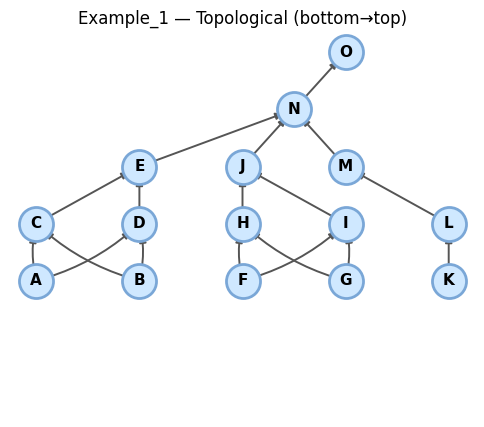

Graph summary:
  nodes=15  edges=18  depth=5
  sources=['A', 'B', 'F', 'G', 'K']  sinks=['O']


,shape,min,max,mean,dtype
0,"(15, 3, 3)",100.0,379.0,209.555556,float64


Gen 000: best=-442.900000 | mean=-500.340000 | median=-494.500000
Gen 001: best=-442.900000 | mean=-471.170000 | median=-466.525000
Gen 002: best=-442.900000 | mean=-459.450000 | median=-460.825000
Gen 003: best=-433.600000 | mean=-457.570000 | median=-453.400000
Gen 004: best=-428.650000 | mean=-452.665000 | median=-450.100000
Gen 005: best=-428.650000 | mean=-446.375000 | median=-445.600000
Gen 006: best=-428.650000 | mean=-441.110000 | median=-440.500000
Gen 007: best=-427.300000 | mean=-439.800000 | median=-436.150000
Gen 008: best=-427.300000 | mean=-432.980000 | median=-433.600000
Gen 009: best=-422.350000 | mean=-435.585000 | median=-428.650000
Gen 010: best=-422.350000 | mean=-428.830000 | median=-428.650000

Optimization result:
  method         : flat
  best_utility   : -422.350000
  best_genome    : [0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1]
  meta           : {'genome_shape': 20, 'generations': 10, 'popsize': 30, 'parents': 15, 'mutation_rate': 0.05, 'fix_

In [ ]:
# --- Run selected case end-to-end
case_key = "Example_1"
CASE = CASES[case_key]

G_links: List[Tuple[str, str]] = CASE["graph"]
P = CASE["price_matrix"]

# Agents attached with graph's goods
goods = sorted({n for u, v in G_links for n in (u, v)})
AGENTS = attach_goods_to_agents(BASE_AGENTS, goods)

# 1) Graph rendering (topological, bottom->top)
G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"{case_key} — Topological (bottom→top)")
plt.show()

# 2) Structural description
sources = [n for n, d in G.in_degree() if d == 0]
sinks = [n for n, d in G.out_degree() if d == 0]
depth = len(list(nx.topological_generations(G))) if nx.is_directed_acyclic_graph(G) else None
print("Graph summary:")
print(f"  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}  depth={depth}")
print(f"  sources={sources}  sinks={sinks}")

# 3) Price matrix description
display(describe_price_matrix(P))

# 4) Optimization
runner = RUNNERS[METHOD]
hp = CASE["hparams"][METHOD]
res = runner(G_links, P, AGENTS, hp)

# Standardize outputs across methods
best_genome = np.array(res["best_genome"], dtype=int)
best_utility = float(res.get("best_utility") or res.get("best_fitness") or res.get("best_score", 0.0))

print("\nOptimization result:")
print(f"  method         : {METHOD}")
print(f"  best_utility   : {best_utility:.6f}")
print(f"  best_genome    : {best_genome.tolist()}")
if "meta" in res:
    print(f"  meta           : {res['meta']}")

# 4bis) All maximizing genomes (ties)
def _as_list(g):
    return list(map(int, np.asarray(g, dtype=int).tolist()))

# Obtain directly what the runner returns; if not present, falls back to best_genome
maximizers_raw = res.get("all_best_genomes", [best_genome.tolist()])

# Deduplicate preserving order
seen = set()
maximizers = []
for g in maximizers_raw:
    key = tuple(_as_list(g))
    if key not in seen:
        seen.add(key)
        maximizers.append(list(key))

total_maximizers = len(maximizers)
show_k = min(10, total_maximizers)

print("\nMaximizing genomes (ties):")
print(f"  total = {total_maximizers} (showing up to {show_k})")
for i, g in enumerate(maximizers[:show_k], 1):
    print(f"  #{i:02d}: {g}")

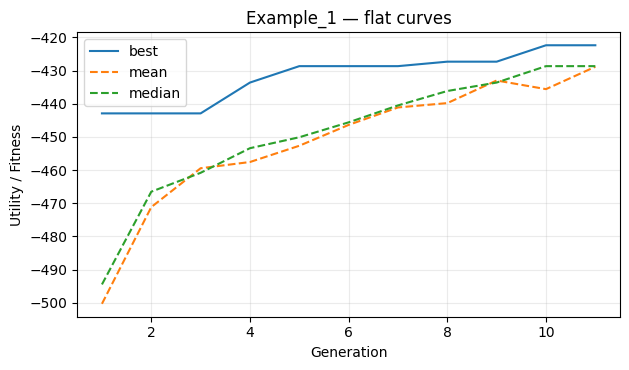

In [ ]:
# GA plots (no file saving, notebook-only rendering)

def _extract_series_for_plot(curves: dict):
    """
    Normalizes the runner's 'curves' dict into a list of series to plot.
    It supports:
      - Flat/Joint GA: keys 'best', 'mean', 'median'
      - Exhaustive GA: keys 'best_combo_best', 'best_combo_mean', 'global_best', 'global_mean'
    Returns a list of tuples: (label, y_values, linestyle).
    """
    series = []
    if not curves:
        return series

    # Flat / Joint runners
    if curves.get("best"):
        series.append(("best",   curves["best"],   "-"))
    if curves.get("mean"):
        series.append(("mean",   curves["mean"],   "--"))
    if curves.get("median"):
        series.append(("median", curves["median"], "--"))

    # Exhaustive runner
    if curves.get("best_combo_best"):
        series.append(("best combo (best)", curves["best_combo_best"], "-"))
    if curves.get("best_combo_mean"):
        series.append(("best combo (mean)", curves["best_combo_mean"], "--"))
    if curves.get("global_best"):
        series.append(("global (best)",     curves["global_best"],     "-"))
    if curves.get("global_mean"):
        series.append(("global (mean)",     curves["global_mean"],     "--"))

    return series


def plot_ga_result(res: dict, method: str, case_key: str):
    """
    Plots GA evolution curves based on the runner's standardized output.
    It does not save any files; it only shows figures in the notebook.
    If 'best_by_selectors' is present (joint GA), it also renders a small bar chart.
    """
    curves = res.get("curves", {}) or {}
    series = _extract_series_for_plot(curves)

    # Evolution curves
    if series:
        fig = plt.figure(figsize=(6.4, 3.8))
        ax = fig.add_subplot(111)
        for label, y, ls in series:
            if not y:
                continue
            x = range(1, len(y) + 1)
            ax.plot(x, y, linestyle=ls, label=label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Utility / Fitness")
        title = f"{case_key} — {method} curves"
        meta = res.get("meta") or {}
        if "num_best_genomes" in meta:
            title += f" (ties={meta['num_best_genomes']})"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()
    else:
        print("No curve data to plot in res['curves'].")

    # Diagnostic chart for joint GA (if provided)
    bsel = res.get("best_by_selectors")
    if bsel:
        # bsel is a list of (selector_tuple_str, best_utility), sorted desc by utility.
        labels = [k for k, _ in bsel[:20]]
        vals   = [float(v) for _k, v in bsel[:20]]
        fig2 = plt.figure(figsize=(6.4, 4.6))
        ax2 = fig2.add_subplot(111)
        y_pos = list(range(len(labels)))[::-1]
        ax2.barh(y_pos, vals)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Best utility per selector combination")
        ax2.set_title(f"{case_key} — {method}: top selector-combos (≤20)")
        fig2.tight_layout()
        plt.show()


# Invoke plotting for the current run (no saving)
plot_ga_result(res, METHOD, case_key)


In [ ]:
# --- Optional: launch interactive GUI to inspect the optimum

import subprocess
import sys
import os 
import json
from textwrap import indent
from pathlib import Path
import numpy as np

# --- 1. Define REPO_ROOT and GUI_PATH ---

REPO_ROOT = Path.cwd().parent
GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"

# --- 2. Data Preparation for GUI Injection ---
# Prepare string representations of the data that the GUI expects in the exact format.
# IMPORTANT: Convert NumPy arrays to string representations that ast.literal_eval can read (lists/arrays).
# The GUI's 'safe_eval_list' relies on this string format.
graph_links_str = str(G_links)
price_matrix_str = str(P.tolist()).replace('],', '],\n').replace('[[[', '[[[\n') # Formatting for readability in the GUI
genome_str = str(best_genome.tolist())

# --- 3. Set Environment Variables BEFORE Launching Subprocess ---
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = genome_str
os.environ["ECON_AUTO_RUN"] = "1" # Optionally, tell the GUI to run the model automatically

# ------------------------------------------

print("GUI handoff summary:")
print("graph_links =")
print(indent(graph_links_str, "  "))
print("price_matrix shape:", P.shape)
print("best_genome length:", len(best_genome))
print(f"GUI path check: {GUI_PATH.exists()}")

def launch_gui(open_now: bool = True):
    """
    Launches the external GUI script by setting environment variables for data transfer.
    """
    if not GUI_PATH.exists():
        print(f"GUI script not found at: {GUI_PATH}")
        return
    
    # The command needs to launch the Python executable with the script path.
    cmd_list = [
        sys.executable,        # Full path to the Python executable
        str(GUI_PATH)          # Full path to the GUI script
    ]
    
    print("Launching:", " ".join(cmd_list))
    
    if open_now:
        # Popen is called. The environment variables set above will be passed to this subprocess.
        subprocess.Popen(cmd_list, shell=False)

# The flag is set to True to open the GUI immediately after this cell runs.
open_immediately = True

if open_immediately:
    launch_gui(open_now=True)

# IMPORTANT: Reset environment variables after launch to avoid polluting future notebook runs
del os.environ["ECON_LINKS"]
del os.environ["ECON_PRICE_MATRIX"]
del os.environ["ECON_GENOME"]
del os.environ["ECON_AUTO_RUN"]

GUI handoff summary:
graph_links =
  [('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('F', 'H'), ('F', 'I'), ('G', 'H'), ('G', 'I'), ('H', 'J'), ('I', 'J'), ('K', 'L'), ('L', 'M'), ('E', 'N'), ('J', 'N'), ('M', 'N'), ('N', 'O')]
price_matrix shape: (15, 3, 3)
best_genome length: 20
GUI path check: True
Launching: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py


# Old Joint

In [ ]:
METHOD = "old_joint"

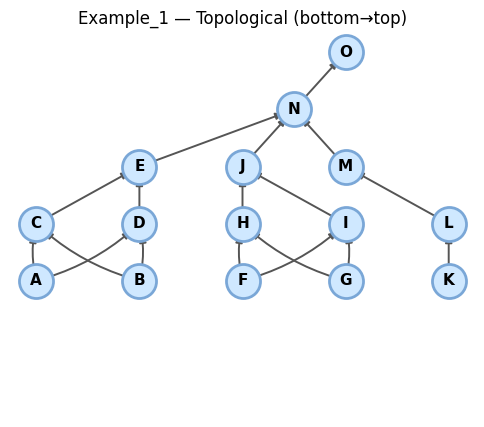

Graph summary:
  nodes=15  edges=18  depth=5
  sources=['A', 'B', 'F', 'G', 'K']  sinks=['O']


,shape,min,max,mean,dtype
0,"(15, 3, 3)",100.0,379.0,209.555556,float64


=== Joint GA detection summary ===
Goods (Planner order): ['A', 'B', 'F', 'G', 'K']
k_g per good: [2, 2, 2, 2, 1]  ->  K=9 | L_used=20
Alphabet for prefix: [0, 1]  (|A|=2)
Per-good pool sizes: [3, 3, 3, 3, 2]  (≈ product 162)
Internal chromosome: selectors=5, tail=11 (total=16)
Gen 000: best=-438.700000 | mean=-498.165000 | median=-485.950000
Gen 001: best=-432.400000 | mean=-465.885000 | median=-465.325000
Gen 002: best=-432.400000 | mean=-456.065000 | median=-455.200000
Gen 003: best=-428.650000 | mean=-448.120000 | median=-447.400000
Gen 004: best=-427.300000 | mean=-443.775000 | median=-442.075000
Gen 005: best=-427.300000 | mean=-438.350000 | median=-434.875000
Gen 006: best=-422.350000 | mean=-431.845000 | median=-432.400000
Gen 007: best=-422.350000 | mean=-428.810000 | median=-427.300000
Gen 008: best=-422.350000 | mean=-427.025000 | median=-427.300000
Gen 009: best=-422.350000 | mean=-426.425000 | median=-427.300000
Gen 010: best=-422.350000 | mean=-424.240000 | median=-422.35

In [ ]:
# --- Run selected case end-to-end
case_key = "Example_1"
CASE = CASES[case_key]

G_links: List[Tuple[str, str]] = CASE["graph"]
P = CASE["price_matrix"]

# Agents attached with graph's goods
goods = sorted({n for u, v in G_links for n in (u, v)})
AGENTS = attach_goods_to_agents(BASE_AGENTS, goods)

# 1) Graph rendering (topological, bottom->top)
G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"{case_key} — Topological (bottom→top)")
plt.show()

# 2) Structural description
sources = [n for n, d in G.in_degree() if d == 0]
sinks = [n for n, d in G.out_degree() if d == 0]
depth = len(list(nx.topological_generations(G))) if nx.is_directed_acyclic_graph(G) else None
print("Graph summary:")
print(f"  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}  depth={depth}")
print(f"  sources={sources}  sinks={sinks}")

# 3) Price matrix description
display(describe_price_matrix(P))

# 4) Optimization
runner = RUNNERS[METHOD]
hp = CASE["hparams"][METHOD]
res = runner(G_links, P, AGENTS, hp)

# Standardize outputs across methods
best_genome = np.array(res["best_genome"], dtype=int)
best_utility = float(res.get("best_utility") or res.get("best_fitness") or res.get("best_score", 0.0))

print("\nOptimization result:")
print(f"  method         : {METHOD}")
print(f"  best_utility   : {best_utility:.6f}")
print(f"  best_genome    : {best_genome.tolist()}")
if "meta" in res:
    print(f"  meta           : {res['meta']}")

# 4bis) All maximizing genomes (ties)
def _as_list(g):
    return list(map(int, np.asarray(g, dtype=int).tolist()))

# Obtain directly what the runner returns; if not present, falls back to best_genome
maximizers_raw = res.get("all_best_genomes", [best_genome.tolist()])

# Deduplicate preserving order
seen = set()
maximizers = []
for g in maximizers_raw:
    key = tuple(_as_list(g))
    if key not in seen:
        seen.add(key)
        maximizers.append(list(key))

total_maximizers = len(maximizers)
show_k = min(10, total_maximizers)

print("\nMaximizing genomes (ties):")
print(f"  total = {total_maximizers} (showing up to {show_k})")
for i, g in enumerate(maximizers[:show_k], 1):
    print(f"  #{i:02d}: {g}")

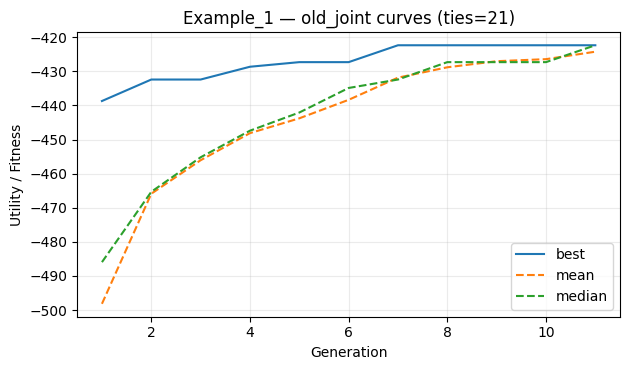

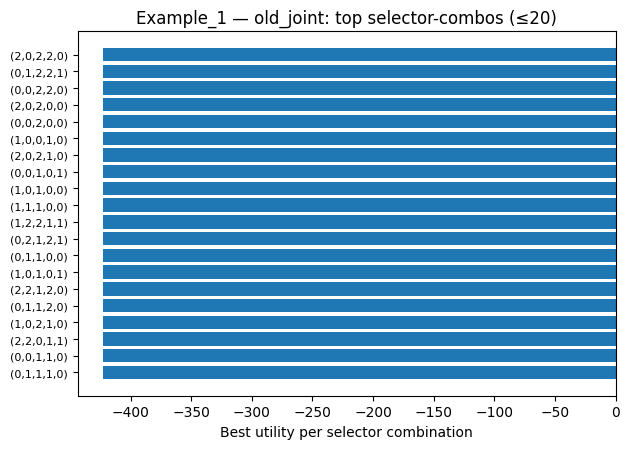

In [ ]:
# GA plots (no file saving, notebook-only rendering)

def _extract_series_for_plot(curves: dict):
    """
    Normalizes the runner's 'curves' dict into a list of series to plot.
    It supports:
      - Flat/Joint GA: keys 'best', 'mean', 'median'
      - Exhaustive GA: keys 'best_combo_best', 'best_combo_mean', 'global_best', 'global_mean'
    Returns a list of tuples: (label, y_values, linestyle).
    """
    series = []
    if not curves:
        return series

    # Flat / Joint runners
    if curves.get("best"):
        series.append(("best",   curves["best"],   "-"))
    if curves.get("mean"):
        series.append(("mean",   curves["mean"],   "--"))
    if curves.get("median"):
        series.append(("median", curves["median"], "--"))

    # Exhaustive runner
    if curves.get("best_combo_best"):
        series.append(("best combo (best)", curves["best_combo_best"], "-"))
    if curves.get("best_combo_mean"):
        series.append(("best combo (mean)", curves["best_combo_mean"], "--"))
    if curves.get("global_best"):
        series.append(("global (best)",     curves["global_best"],     "-"))
    if curves.get("global_mean"):
        series.append(("global (mean)",     curves["global_mean"],     "--"))

    return series


def plot_ga_result(res: dict, method: str, case_key: str):
    """
    Plots GA evolution curves based on the runner's standardized output.
    It does not save any files; it only shows figures in the notebook.
    If 'best_by_selectors' is present (joint GA), it also renders a small bar chart.
    """
    curves = res.get("curves", {}) or {}
    series = _extract_series_for_plot(curves)

    # Evolution curves
    if series:
        fig = plt.figure(figsize=(6.4, 3.8))
        ax = fig.add_subplot(111)
        for label, y, ls in series:
            if not y:
                continue
            x = range(1, len(y) + 1)
            ax.plot(x, y, linestyle=ls, label=label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Utility / Fitness")
        title = f"{case_key} — {method} curves"
        meta = res.get("meta") or {}
        if "num_best_genomes" in meta:
            title += f" (ties={meta['num_best_genomes']})"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()
    else:
        print("No curve data to plot in res['curves'].")

    # Diagnostic chart for joint GA (if provided)
    bsel = res.get("best_by_selectors")
    if bsel:
        # bsel is a list of (selector_tuple_str, best_utility), sorted desc by utility.
        labels = [k for k, _ in bsel[:20]]
        vals   = [float(v) for _k, v in bsel[:20]]
        fig2 = plt.figure(figsize=(6.4, 4.6))
        ax2 = fig2.add_subplot(111)
        y_pos = list(range(len(labels)))[::-1]
        ax2.barh(y_pos, vals)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Best utility per selector combination")
        ax2.set_title(f"{case_key} — {method}: top selector-combos (≤20)")
        fig2.tight_layout()
        plt.show()


# Invoke plotting for the current run (no saving)
plot_ga_result(res, METHOD, case_key)


In [ ]:
# --- Optional: launch interactive GUI to inspect the optimum

import subprocess
import sys
import os 
import json
from textwrap import indent
from pathlib import Path
import numpy as np

# --- 1. Define REPO_ROOT and GUI_PATH ---

REPO_ROOT = Path.cwd().parent
GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"

# --- 2. Data Preparation for GUI Injection ---
# Prepare string representations of the data that the GUI expects in the exact format.
# IMPORTANT: Convert NumPy arrays to string representations that ast.literal_eval can read (lists/arrays).
# The GUI's 'safe_eval_list' relies on this string format.
graph_links_str = str(G_links)
price_matrix_str = str(P.tolist()).replace('],', '],\n').replace('[[[', '[[[\n') # Formatting for readability in the GUI
genome_str = str(best_genome.tolist())

# --- 3. Set Environment Variables BEFORE Launching Subprocess ---
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = genome_str
os.environ["ECON_AUTO_RUN"] = "1" # Optionally, tell the GUI to run the model automatically

# ------------------------------------------

print("GUI handoff summary:")
print("graph_links =")
print(indent(graph_links_str, "  "))
print("price_matrix shape:", P.shape)
print("best_genome length:", len(best_genome))
print(f"GUI path check: {GUI_PATH.exists()}")

def launch_gui(open_now: bool = True):
    """
    Launches the external GUI script by setting environment variables for data transfer.
    """
    if not GUI_PATH.exists():
        print(f"GUI script not found at: {GUI_PATH}")
        return
    
    # The command needs to launch the Python executable with the script path.
    cmd_list = [
        sys.executable,        # Full path to the Python executable
        str(GUI_PATH)          # Full path to the GUI script
    ]
    
    print("Launching:", " ".join(cmd_list))
    
    if open_now:
        # Popen is called. The environment variables set above will be passed to this subprocess.
        subprocess.Popen(cmd_list, shell=False)

# The flag is set to True to open the GUI immediately after this cell runs.
open_immediately = True

if open_immediately:
    launch_gui(open_now=True)

# IMPORTANT: Reset environment variables after launch to avoid polluting future notebook runs
del os.environ["ECON_LINKS"]
del os.environ["ECON_PRICE_MATRIX"]
del os.environ["ECON_GENOME"]
del os.environ["ECON_AUTO_RUN"]

GUI handoff summary:
graph_links =
  [('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('F', 'H'), ('F', 'I'), ('G', 'H'), ('G', 'I'), ('H', 'J'), ('I', 'J'), ('K', 'L'), ('L', 'M'), ('E', 'N'), ('J', 'N'), ('M', 'N'), ('N', 'O')]
price_matrix shape: (15, 3, 3)
best_genome length: 20
GUI path check: True
Launching: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py


# Recombination

In [ ]:
METHOD = "recomb"

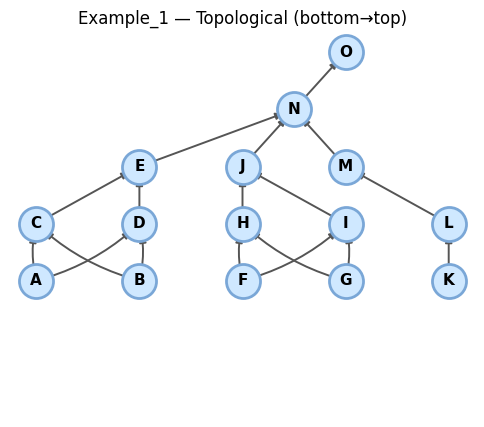

Graph summary:
  nodes=15  edges=18  depth=5
  sources=['A', 'B', 'F', 'G', 'K']  sinks=['O']


,shape,min,max,mean,dtype
0,"(15, 3, 3)",100.0,379.0,209.555556,float64


=== Recombination-only GA detection summary ===
Goods (Planner order)       : ['A', 'B', 'F', 'G', 'K']
k_g per good                : [2, 2, 2, 2, 1]  ->  K=9 | L_used=20
Alphabet for prefix         : [0, 1]  (|A|=2)
Per-good pool sizes         : [3, 3, 3, 3, 2]  (≈ product 162)
Internal chromosome         : selectors=5, tail=11 (total=16)
Operators                   : p_recomb=0.5, sel_mut=0.0625, tail_mut=0.0625, p_min=0.3, mating=pairwise_tournament
Gen 000: best=-438.700000 | mean=-498.165000 | median=-485.950000 | pheno_div=0.4506 | uniq=30
Gen 001: best=-438.700000 | mean=-475.010000 | median=-470.950000 | pheno_div=0.4091 | uniq=12
Gen 002: best=-436.150000 | mean=-462.515000 | median=-464.125000 | pheno_div=0.3295 | uniq=12
Gen 003: best=-427.300000 | mean=-452.880000 | median=-453.325000 | pheno_div=0.3636 | uniq=12
Gen 004: best=-427.300000 | mean=-448.255000 | median=-446.800000 | pheno_div=0.3288 | uniq=12
Gen 005: best=-427.300000 | mean=-443.660000 | median=-446.050000 | 

In [ ]:
# --- Run selected case end-to-end
case_key = "Example_1"
CASE = CASES[case_key]

G_links: List[Tuple[str, str]] = CASE["graph"]
P = CASE["price_matrix"]

# Agents attached with graph's goods
goods = sorted({n for u, v in G_links for n in (u, v)})
AGENTS = attach_goods_to_agents(BASE_AGENTS, goods)

# 1) Graph rendering (topological, bottom->top)
G = nx.DiGraph(); G.add_edges_from(G_links)
_ = draw_dag_topo(G, title=f"{case_key} — Topological (bottom→top)")
plt.show()

# 2) Structural description
sources = [n for n, d in G.in_degree() if d == 0]
sinks = [n for n, d in G.out_degree() if d == 0]
depth = len(list(nx.topological_generations(G))) if nx.is_directed_acyclic_graph(G) else None
print("Graph summary:")
print(f"  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}  depth={depth}")
print(f"  sources={sources}  sinks={sinks}")

# 3) Price matrix description
display(describe_price_matrix(P))

# 4) Optimization
runner = RUNNERS[METHOD]
hp = CASE["hparams"][METHOD]
res = runner(G_links, P, AGENTS, hp)

# Standardize outputs across methods
best_genome = np.array(res["best_genome"], dtype=int)
best_utility = float(res.get("best_utility") or res.get("best_fitness") or res.get("best_score", 0.0))

print("\nOptimization result:")
print(f"  method         : {METHOD}")
print(f"  best_utility   : {best_utility:.6f}")
print(f"  best_genome    : {best_genome.tolist()}")
if "meta" in res:
    print(f"  meta           : {res['meta']}")

# 4bis) All maximizing genomes (ties)
def _as_list(g):
    return list(map(int, np.asarray(g, dtype=int).tolist()))

# Obtain directly what the runner returns; if not present, falls back to best_genome
maximizers_raw = res.get("all_best_genomes", [best_genome.tolist()])

# Deduplicate preserving order
seen = set()
maximizers = []
for g in maximizers_raw:
    key = tuple(_as_list(g))
    if key not in seen:
        seen.add(key)
        maximizers.append(list(key))

total_maximizers = len(maximizers)
show_k = min(10, total_maximizers)

print("\nMaximizing genomes (ties):")
print(f"  total = {total_maximizers} (showing up to {show_k})")
for i, g in enumerate(maximizers[:show_k], 1):
    print(f"  #{i:02d}: {g}")

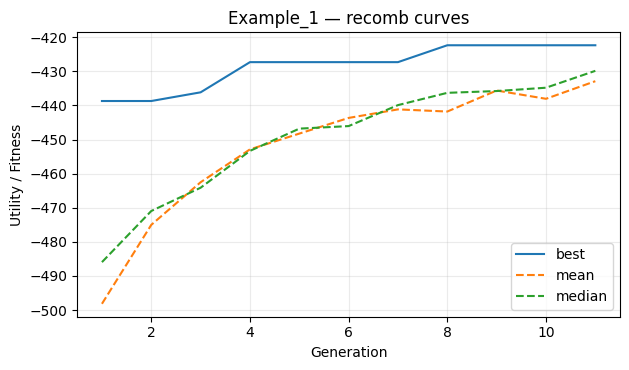

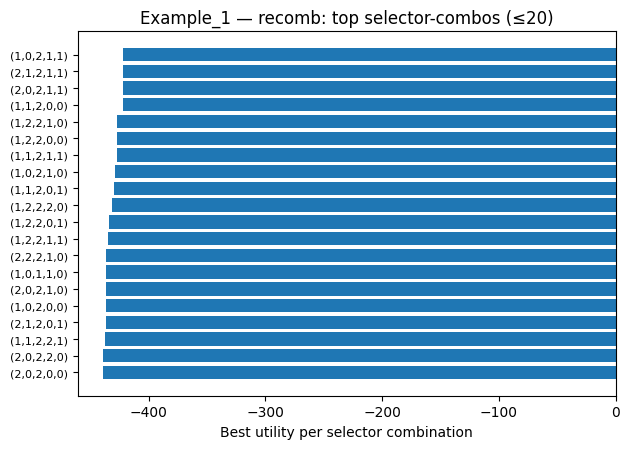

In [ ]:
# GA plots (no file saving, notebook-only rendering)

def _extract_series_for_plot(curves: dict):
    """
    Normalizes the runner's 'curves' dict into a list of series to plot.
    It supports:
      - Flat/Joint GA: keys 'best', 'mean', 'median'
      - Exhaustive GA: keys 'best_combo_best', 'best_combo_mean', 'global_best', 'global_mean'
    Returns a list of tuples: (label, y_values, linestyle).
    """
    series = []
    if not curves:
        return series

    # Flat / Joint runners
    if curves.get("best"):
        series.append(("best",   curves["best"],   "-"))
    if curves.get("mean"):
        series.append(("mean",   curves["mean"],   "--"))
    if curves.get("median"):
        series.append(("median", curves["median"], "--"))

    # Exhaustive runner
    if curves.get("best_combo_best"):
        series.append(("best combo (best)", curves["best_combo_best"], "-"))
    if curves.get("best_combo_mean"):
        series.append(("best combo (mean)", curves["best_combo_mean"], "--"))
    if curves.get("global_best"):
        series.append(("global (best)",     curves["global_best"],     "-"))
    if curves.get("global_mean"):
        series.append(("global (mean)",     curves["global_mean"],     "--"))

    return series


def plot_ga_result(res: dict, method: str, case_key: str):
    """
    Plots GA evolution curves based on the runner's standardized output.
    It does not save any files; it only shows figures in the notebook.
    If 'best_by_selectors' is present (joint GA), it also renders a small bar chart.
    """
    curves = res.get("curves", {}) or {}
    series = _extract_series_for_plot(curves)

    # Evolution curves
    if series:
        fig = plt.figure(figsize=(6.4, 3.8))
        ax = fig.add_subplot(111)
        for label, y, ls in series:
            if not y:
                continue
            x = range(1, len(y) + 1)
            ax.plot(x, y, linestyle=ls, label=label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Utility / Fitness")
        title = f"{case_key} — {method} curves"
        meta = res.get("meta") or {}
        if "num_best_genomes" in meta:
            title += f" (ties={meta['num_best_genomes']})"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()
    else:
        print("No curve data to plot in res['curves'].")

    # Diagnostic chart for joint GA (if provided)
    bsel = res.get("best_by_selectors")
    if bsel:
        # bsel is a list of (selector_tuple_str, best_utility), sorted desc by utility.
        labels = [k for k, _ in bsel[:20]]
        vals   = [float(v) for _k, v in bsel[:20]]
        fig2 = plt.figure(figsize=(6.4, 4.6))
        ax2 = fig2.add_subplot(111)
        y_pos = list(range(len(labels)))[::-1]
        ax2.barh(y_pos, vals)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(labels, fontsize=8)
        ax2.set_xlabel("Best utility per selector combination")
        ax2.set_title(f"{case_key} — {method}: top selector-combos (≤20)")
        fig2.tight_layout()
        plt.show()


# Invoke plotting for the current run (no saving)
plot_ga_result(res, METHOD, case_key)


In [ ]:
# --- Optional: launch interactive GUI to inspect the optimum

import subprocess
import sys
import os 
import json
from textwrap import indent
from pathlib import Path
import numpy as np

# --- 1. Define REPO_ROOT and GUI_PATH ---

REPO_ROOT = Path.cwd().parent
GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"

# --- 2. Data Preparation for GUI Injection ---
# Prepare string representations of the data that the GUI expects in the exact format.
# IMPORTANT: Convert NumPy arrays to string representations that ast.literal_eval can read (lists/arrays).
# The GUI's 'safe_eval_list' relies on this string format.
graph_links_str = str(G_links)
price_matrix_str = str(P.tolist()).replace('],', '],\n').replace('[[[', '[[[\n') # Formatting for readability in the GUI
genome_str = str(best_genome.tolist())

# --- 3. Set Environment Variables BEFORE Launching Subprocess ---
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = genome_str
os.environ["ECON_AUTO_RUN"] = "1" # Optionally, tell the GUI to run the model automatically

# ------------------------------------------

print("GUI handoff summary:")
print("graph_links =")
print(indent(graph_links_str, "  "))
print("price_matrix shape:", P.shape)
print("best_genome length:", len(best_genome))
print(f"GUI path check: {GUI_PATH.exists()}")

def launch_gui(open_now: bool = True):
    """
    Launches the external GUI script by setting environment variables for data transfer.
    """
    if not GUI_PATH.exists():
        print(f"GUI script not found at: {GUI_PATH}")
        return
    
    # The command needs to launch the Python executable with the script path.
    cmd_list = [
        sys.executable,        # Full path to the Python executable
        str(GUI_PATH)          # Full path to the GUI script
    ]
    
    print("Launching:", " ".join(cmd_list))
    
    if open_now:
        # Popen is called. The environment variables set above will be passed to this subprocess.
        subprocess.Popen(cmd_list, shell=False)

# The flag is set to True to open the GUI immediately after this cell runs.
open_immediately = True

if open_immediately:
    launch_gui(open_now=True)

# IMPORTANT: Reset environment variables after launch to avoid polluting future notebook runs
del os.environ["ECON_LINKS"]
del os.environ["ECON_PRICE_MATRIX"]
del os.environ["ECON_GENOME"]
del os.environ["ECON_AUTO_RUN"]

GUI handoff summary:
graph_links =
  [('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('F', 'H'), ('F', 'I'), ('G', 'H'), ('G', 'I'), ('H', 'J'), ('I', 'J'), ('K', 'L'), ('L', 'M'), ('E', 'N'), ('J', 'N'), ('M', 'N'), ('N', 'O')]
price_matrix shape: (15, 3, 3)
best_genome length: 20
GUI path check: True
Launching: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py
